# MNIST Convolutional Neural Network with Keras 3

This complete workflow belongs to [Convolutional Neural Networks](../index.md). Keras and PyTorch use the same
seeded indices, normalization, architecture intent, training budget, metrics,
and diagnostic figures.

In Colab, select **Runtime → Run all**; the canonical dataset is downloaded by
the framework. To run the example more quickly, set `EPOCHS` to 1 or 2 in the
data-loading cell.

## Runtime dependency check

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_RUNTIME = {'keras': 'keras', 'torch': 'torch'}
COLAB_EXTRAS = {}
missing_required = [
    package for module, package in REQUIRED_RUNTIME.items()
    if importlib.util.find_spec(module) is None
]
missing_extras = [
    package for module, package in COLAB_EXTRAS.items()
    if importlib.util.find_spec(module) is None
]
if missing_extras and "google.colab" in sys.modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_extras]
    )
    missing_extras = []
if missing_required or missing_extras:
    missing = ", ".join(missing_required + missing_extras)
    raise RuntimeError(
        f"Missing notebook dependencies: {missing}. Locally run "
        "`uv sync --group notebooks`; in Colab restart the runtime if an "
        "installation cell just changed the environment."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Keras-to-PyTorch crosswalk

This optional implementation uses the same Torch runtime as the canonical
native PyTorch path. Keras `compile()` selects the optimizer and loss,
`fit()` owns the explicit batch and epoch loop, and callbacks provide
high-level training control. Data, splits, budgets, evidence, and scientific
conclusions remain aligned with the canonical PyTorch workflow.

## Imports and reproducibility

In [3]:
import hashlib
import json
import os

os.environ["KERAS_BACKEND"] = "torch"

import keras
import matplotlib.pyplot as plt
import numpy as np
import torch
from keras import layers
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

assert keras.backend.backend() == "torch"
print(
    f"Keras {keras.__version__}; backend={keras.backend.backend()}; "
    f"PyTorch {torch.__version__}"
)

Keras 3.15.1; backend=torch; PyTorch 2.13.0


## Load data and create the shared split

In [4]:
SEED = 42
EPOCHS = 5  # Reduce to 1 or 2 for a quicker run.
BATCH_SIZE = 256

keras.utils.set_random_seed(SEED)
torch.use_deterministic_algorithms(True)

(x_development, y_development), (x_test, y_test) = keras.datasets.mnist.load_data()
all_indices = np.arange(len(y_development))
train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=10000,
    random_state=SEED,
    stratify=y_development,
)
split_signature = hashlib.sha256(
    validation_indices.astype("<i8").tobytes()
).hexdigest()[:16]

x_train = x_development[train_indices].astype("float32") / 255.0
y_train = y_development[train_indices].astype(np.int64)
x_validation = x_development[validation_indices].astype("float32") / 255.0
y_validation = y_development[validation_indices].astype(np.int64)
x_test = x_test.astype("float32") / 255.0
y_test = y_test.astype(np.int64)
x_train = x_train[..., np.newaxis]
x_validation = x_validation[..., np.newaxis]
x_test = x_test[..., np.newaxis]

assert set(train_indices).isdisjoint(validation_indices)
print(f"split signature: {split_signature}")
print(
    f"train={len(y_train):,}, validation={len(y_validation):,}, "
    f"test={len(y_test):,}, epochs={EPOCHS}"
)

split signature: 829d1431018b38bc
train=50,000, validation=10,000, test=10,000, epochs=5


## Inspect class coverage

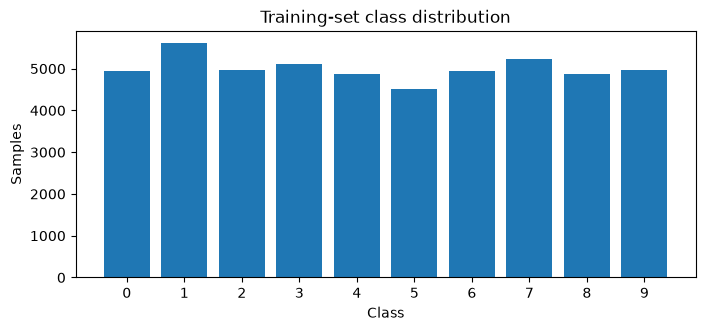

In [5]:
training_counts = np.bincount(y_train, minlength=10)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(np.arange(10), training_counts)
ax.set(
    title="Training-set class distribution",
    xlabel="Class",
    ylabel="Samples",
    xticks=np.arange(10),
)
plt.show()

## Define the model

In [6]:
model = keras.Sequential(
    [
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(200, activation="relu"),
        layers.Dense(150, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10),
    ],
    name="mnist_cnn",
)

## Train with validation evidence

Model: "mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       320,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 150)            │        30,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 370,676 (1.41 MB)

 Trainable params: 370,676 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

...

196/196 - 7s - 37ms/step - accuracy: 0.9778 - loss: 0.0741 - val_accuracy: 0.9855 - val_loss: 0.0490


Epoch 4/5


196/196 - 7s - 37ms/step - accuracy: 0.9833 - loss: 0.0578 - val_accuracy: 0.9875 - val_loss: 0.0426


Epoch 5/5


196/196 - 7s - 37ms/step - accuracy: 0.9858 - loss: 0.0468 - val_accuracy: 0.9892 - val_loss: 0.0371


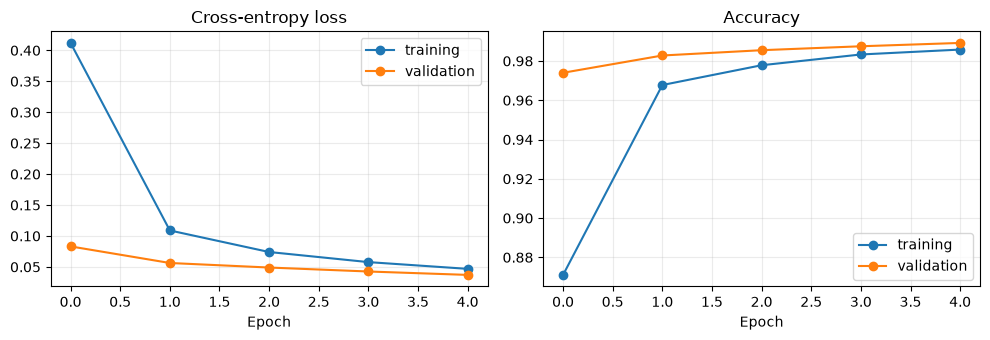

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
model.summary()
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_validation, y_validation),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history.history["loss"], marker="o", label="training")
axes[0].plot(history.history["val_loss"], marker="o", label="validation")
axes[0].set(title="Cross-entropy loss", xlabel="Epoch")
axes[1].plot(history.history["accuracy"], marker="o", label="training")
axes[1].plot(history.history["val_accuracy"], marker="o", label="validation")
axes[1].set(title="Accuracy", xlabel="Epoch")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Evaluate once on the test set

test accuracy: 0.9911
              precision    recall  f1-score   support

           0      0.988     0.996     0.992       980
           1      0.996     0.996     0.996      1135
           2      0.988     0.995     0.992      1032
           3      0.996     0.987     0.992      1010
           4      0.991     0.996     0.993       982
           5      0.987     0.991     0.989       892
           6      0.996     0.994     0.995       958
           7      0.985     0.990     0.988      1028
           8      0.991     0.991     0.991       974
           9      0.993     0.974     0.983      1009

    accuracy                          0.991     10000
   macro avg      0.991     0.991     0.991     10000
weighted avg      0.991     0.991     0.991     10000

HELIO_RESULT {"confusion_shape": [10, 10], "split_signature": "829d1431018b38bc", "test_accuracy": 0.9911}


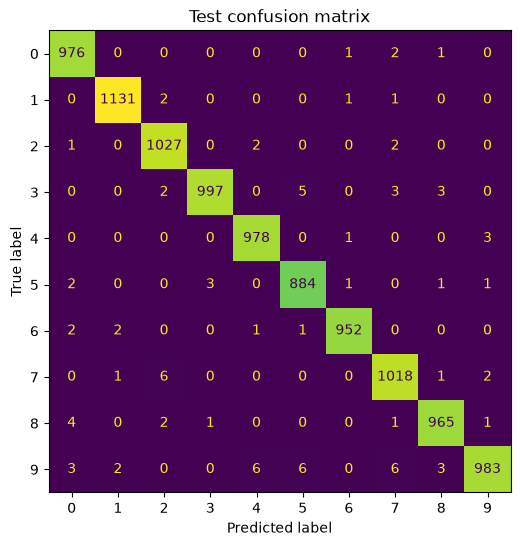

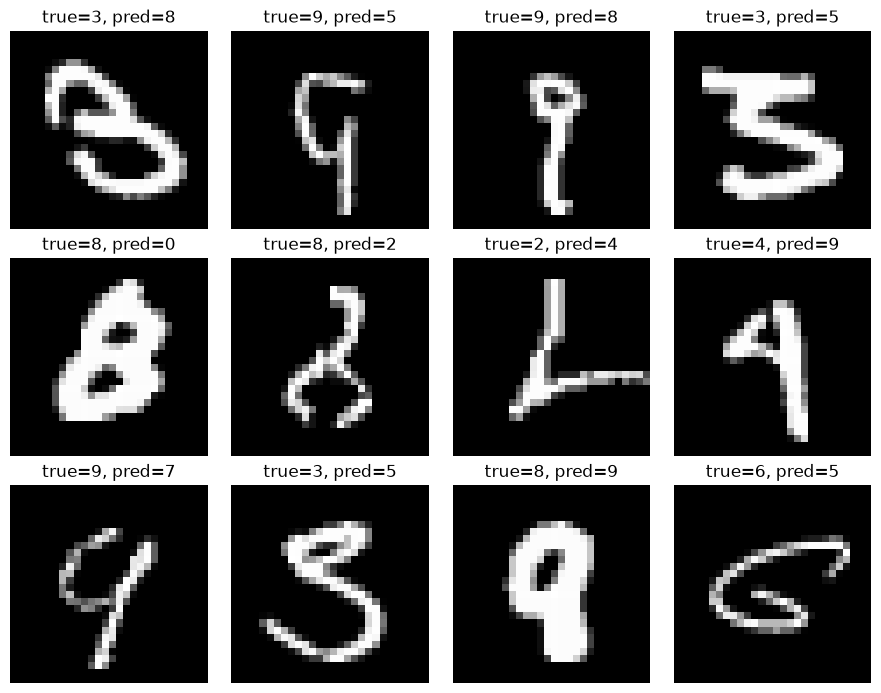

In [8]:
test_logits = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
test_predictions = test_logits.argmax(axis=1)

test_accuracy = accuracy_score(y_test, test_predictions)
cm = confusion_matrix(y_test, test_predictions, labels=np.arange(10))
print(f"test accuracy: {test_accuracy:.4f}")
print(
    classification_report(
        y_test,
        test_predictions,
        labels=np.arange(10),
        digits=3,
        zero_division=0,
    )
)
print(
    "HELIO_RESULT "
    + json.dumps(
        {
            "split_signature": split_signature,
            "test_accuracy": float(test_accuracy),
            "confusion_shape": list(cm.shape),
        },
        sort_keys=True,
    )
)
assert cm.shape == (10, 10)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=np.arange(10)).plot(
    ax=ax, colorbar=False, values_format="d"
)
ax.set_title("Test confusion matrix")
plt.show()

mistakes = np.flatnonzero(test_predictions != y_test)[:12]
if len(mistakes):
    fig, axes = plt.subplots(3, 4, figsize=(9, 7))
    for axis, index in zip(axes.flat, mistakes):
        image = x_test[index]
        if image.shape[0] in (1, 3):
            image = np.transpose(image, (1, 2, 0))
        axis.imshow(image.squeeze(), cmap="gray" if image.squeeze().ndim == 2 else None)
        axis.set_title(f"true={y_test[index]}, pred={test_predictions[index]}")
        axis.axis("off")
    plt.tight_layout()
    plt.show()

## Try it yourself in Keras

Change one choice at a time and keep the data split and evaluation unchanged:

- change the first convolution from 32 to 64 filters.
- compare 3×3 and 5×5 kernels.
- remove one pooling operation and inspect the tensor shapes.